# Version 2 Department and Location History Audit

This notebook is the authoritative Version 2 successor to Notebook 19. It verifies department continuity and location-transfer reconstruction on the synthetic temporal data used by the current project.

The audit is target-free and saves aggregate evidence only.

**Portfolio navigation:** [Notebook index](README.md) · [V2 history report](../docs/v2_department_history.md) · [Previous: V2 EDA](37_v2_exploratory_analysis.ipynb)


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
OUTPUT = PROJECT_ROOT / "data" / "processed" / "v2_department_history"
print("Loaded aggregate Version 2 history-attribution evidence.")


Loaded aggregate Version 2 history-attribution evidence.


## Headline history contract

Department is invariant by generator design. Location may change through dated transfer events.


In [2]:
summary = pd.read_csv(OUTPUT / "department_history_summary.csv")
display(summary)


,metric,value,unit
0,Source employees,10000,rows
1,Hire events,10000,events
2,Parsed hire departments,10000,events
3,Hire-to-current department mismatches,0,employees
4,Current location differs from hire,107,employees
5,Transfer events,486,events
6,Employees with transfer events,486,employees
7,Location-semantic transfer events,486,events
8,Department-semantic transfer events,0,events
9,Panel unique employees,7745,employees


## Transfer-event semantics

All 486 transfer events represent location changes; zero represent department changes. Reading them as department history would invent false assignments.


In [3]:
events = pd.read_csv(OUTPUT / "event_type_summary.csv")
display(events)


,event_type,events,unique_employees
0,Hire,10000,10000
1,Termination,2591,2591
2,Manager Change,2337,2305
3,Promotion,1897,1680
4,Leave,878,439
5,Transfer,486,486


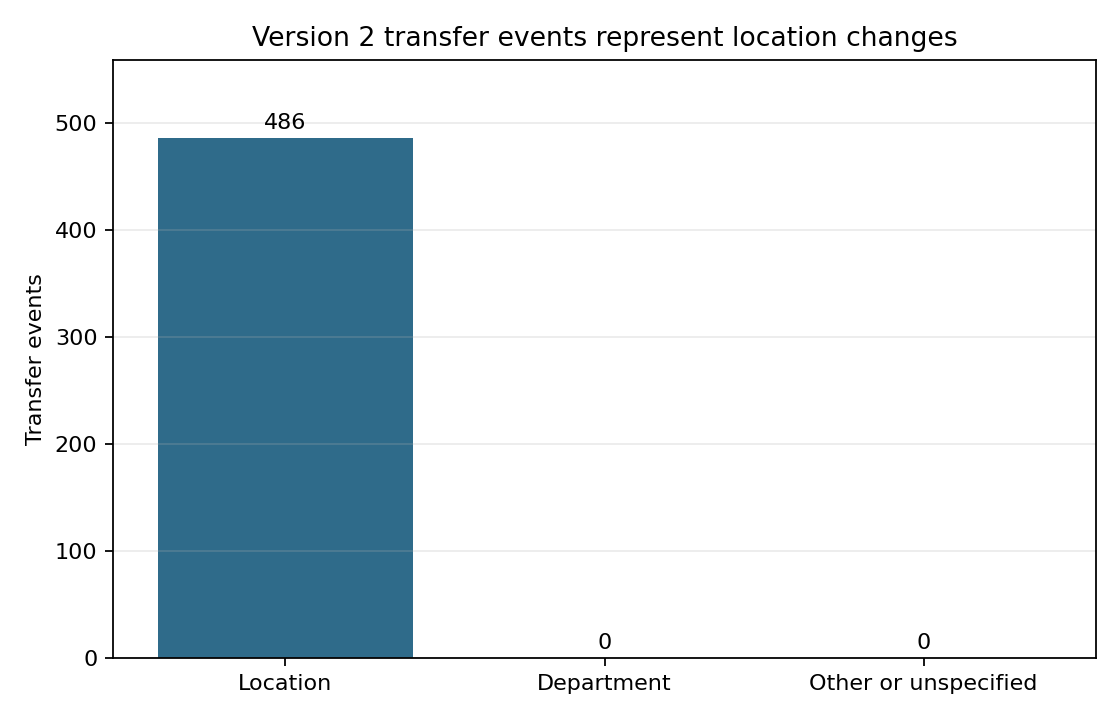

In [4]:
display(Image(filename=OUTPUT / "transfer_event_semantics.png"))


## Department continuity

All 7,745 employees appearing in the historical panel retain one department across observed snapshots.


In [5]:
continuity = pd.read_csv(OUTPUT / "department_continuity_summary.csv")
display(continuity)


,department_name,source_employees,panel_employees,employees_with_multiple_panel_departments
0,Manufacturing,2499,1936,0
1,Engineering,2000,1580,0
2,Supply Chain,1200,937,0
3,Information Technology,1000,780,0
4,Sales,1000,777,0
5,Customer Support,800,602,0
6,Finance,800,608,0
7,Human Resources,701,525,0


## Historical location reconstruction

Eighty-six historical rows covering 60 employees correctly differ from the employee's current location. This is evidence that dated transfers, rather than final-location backfill, drive snapshot location.


In [6]:
reconstruction = pd.read_csv(OUTPUT / "location_reconstruction_summary.csv")
display(reconstruction)


,snapshot_sequence,rows,unique_employees,reconstructed_rows,reconstructed_employees
0,1,4303,4303,31,31
1,2,5625,5625,34,34
2,3,6745,6745,21,21


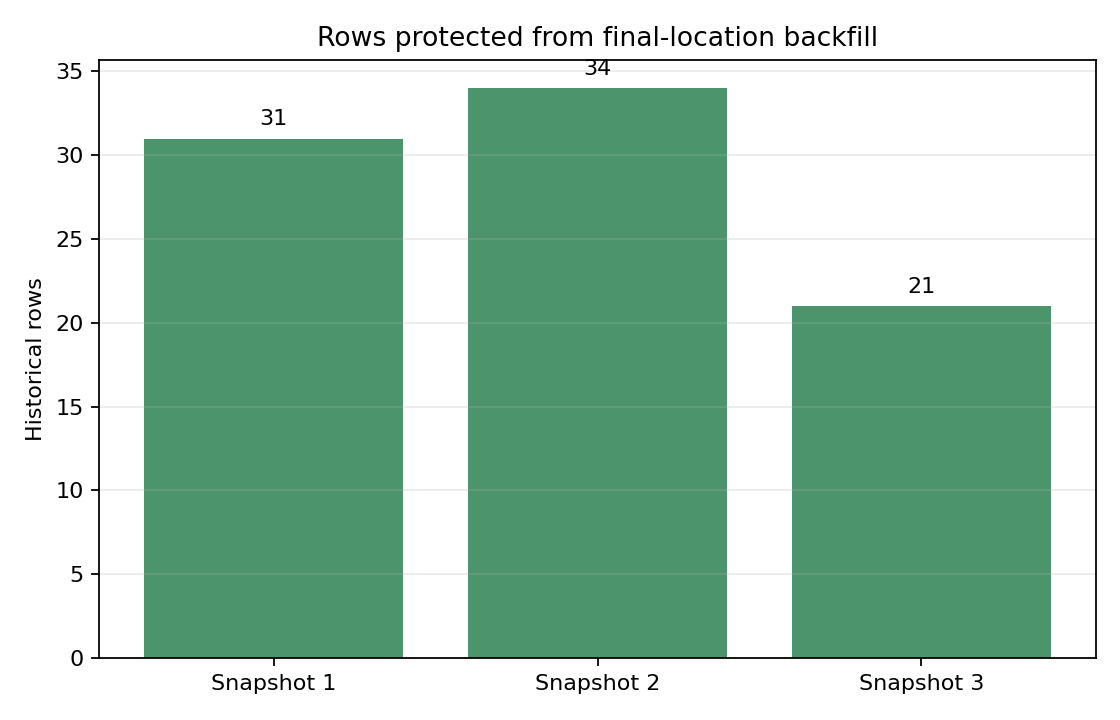

In [7]:
display(Image(filename=OUTPUT / "historical_location_reconstruction.png"))


## Validation and limitation

The zero department mismatch is a generator limitation, not proof that real department mobility is solved. Production data would need effective-dated department assignments.


In [8]:
checks = pd.read_csv(OUTPUT / "validation_checks.csv")
display(checks[["check", "status", "details"]])
assert checks["status"].eq("PASS").all()
print(f"Checks passed: {len(checks)}/{len(checks)}")


,check,status,details
0,Version 2 source and hire populations reconcile,PASS,Every Version 2 employee has a parseable hire ...
1,Hire department remains the current department,PASS,"Department is invariant by generator design, n..."
2,Transfer events are explicitly location-semantic,PASS,Notebook 19's hypothesis is re-audited on Vers...
3,Temporal panel contains no department changes,PASS,No current department is backfilled into a cha...
4,Location history is reconstructed rather than ...,PASS,Dated location transfers prevent final-locatio...
5,Current and hire locations are not assumed ide...,PASS,The audit distinguishes immutable department f...
6,Saved history outputs are aggregate and target...,PASS,The audit exports neither employee identifiers...
7,History audit preserves Version 2 analytical r...,PASS,Checkpoint 66 replaces the missing V2 evidence...


Checks passed: 8/8
